In [3]:
library("variancePartition")
library("BiocParallel")

In [4]:
# path to files
path_to_T7 = "/media/caio/T7_Shield/PhD/BEPE/Backup/Tracy_Server_Backup/Nickole_Study_2024/analysis"
path = paste(path_to_T7,"/data_for_modeling.csv",sep="")
info_to_modeling = read.csv(path, 
                            row.names = read.csv(path)[,1])[,-1]

#info_to_modeling[which(info_to_modeling$Subject == "50087"),] # show missing data
#info_to_modeling[which(info_to_modeling$Subject == "50087"),] 
info_to_modeling = info_to_modeling[-which(info_to_modeling$Subject == "50087"),]
# remove 087-7 and 087-8 samples because of missing data  
#info_to_modeling = info_to_modeling[-which(info_to_modeling$Sample %in% c("087-7","087-8")),]
info_to_modeling$Subject = as.factor(info_to_modeling$Subject)

length(unique(info_to_modeling$Subject))

[1] 29

In [5]:
path_nickole = "/media/caio/T7_Shield/PhD/BEPE/Backup/Tracy_Server_Backup/Nickole_Study_2024/data_preprocessing/"
miRNA_DGE = readRDS(paste(path_nickole,"DGEList_miRNA_filtered_norm.RDS",sep=""));
miRNA_DGE = miRNA_DGE[,-grep("087",colnames(miRNA_DGE))]

piRNA_DGE = readRDS(paste(path_nickole,"DGEList_piRNA_filtered_norm.RDS",sep=""));
piRNA_DGE = piRNA_DGE[,-grep("087",colnames(piRNA_DGE))]

tRNA_DGE  = readRDS(paste(path_nickole,"DGEList_tRNA_filtered_norm.RDS",sep=""));
tRNA_DGE = tRNA_DGE[,-grep("087",colnames(tRNA_DGE))]

dynamic_candidates  = readRDS(paste(path_nickole,"dynamic_cadidate_all_subjects.RDS",sep=""));

Loading required package: edgeR



In [6]:
miRNA_log2 = edgeR::cpm(miRNA_DGE,log=T,prior.count = 3)
miRNA_log2 = miRNA_log2[,-grep("Sperm",colnames(miRNA_log2))]

piRNA_log2 = edgeR::cpm(piRNA_DGE,log=T,prior.count = 3)
piRNA_log2 = piRNA_log2[,-grep("Sperm",colnames(piRNA_log2))]

tRNA_log2 = edgeR::cpm(tRNA_DGE,log=T,prior.count = 3)
tRNA_log2 = tRNA_log2[,-grep("Sperm",colnames(tRNA_log2))]

In [7]:
sncRNA_expression_list= list(miRNA = miRNA_log2, piRNA = piRNA_log2, tRNA = tRNA_log2)

In [8]:
# dynamic sncRNA classification criteria
dynamic_miRNA = dynamic_candidates$miRNA[(dynamic_candidates$miRNA$dynamic_count >= 7),]$miRNA
dynamic_piRNA = dynamic_candidates$piRNA[(dynamic_candidates$piRNA$dynamic_count >= 7),]$piRNA
dynamic_tRNA = dynamic_candidates$tRNA[(dynamic_candidates$tRNA$dynamic_count >= 7),]$tRNA

### Implementation functions

In [9]:
# calculate voom for each sncRNA class given a particular model specification (i.e. formula)
voom_dream <- function(formula_design){
    voom_miR = voomWithDreamWeights(miRNA_DGE[dynamic_miRNA,info_to_modeling$Sample], formula = formula_design, 
                                    info_to_modeling, lib.size = info_to_modeling$sequence_count)
    voom_piR = voomWithDreamWeights(piRNA_DGE[dynamic_piRNA,info_to_modeling$Sample], formula = formula_design, 
                                    info_to_modeling, lib.size = info_to_modeling$sequence_count)
    voom_tR  = voomWithDreamWeights(tRNA_DGE[dynamic_tRNA,info_to_modeling$Sample], formula = formula_design, 
                                    info_to_modeling, lib.size = info_to_modeling$sequence_count)
    return(list(miR = voom_miR,piR = voom_piR, tR = voom_tR))
}

In [10]:
# apply dream() to voom objects and get model fit 
apply_dream <- function(formula_design, voom_miR, voom_piR, voom_tR){
    fit_miR = dream(voom_miR, formula_design, info_to_modeling)
    fit_piR = dream(voom_piR, formula_design, info_to_modeling)
    fit_tR  = dream(voom_tR, formula_design, info_to_modeling)
    return(list(miR = fit_miR,piR = fit_piR, tR = fit_tR))
}

In [11]:
# produce results table from dream model fit
set_results <- function(dream_object,term_to_plot){
    eBayes_miR <- eBayes(dream_object$miR)
    eBayes_piR <- eBayes(dream_object$piR)
    eBayes_tR <- eBayes(dream_object$tR) 
    results_miR_int <- topTable(eBayes_miR, coef = term_to_plot, adjust.method = "fdr", n = Inf)
    results_miR_int$genes  = gsub("hsa-","",results_miR_int$genes) 
    
    results_piR_int <- topTable(eBayes_piR, coef = term_to_plot, adjust.method = "fdr", n = Inf)
    results_piR_int$genes  = gsub("hsa-","",results_piR_int$genes) 
    
    results_tR_int <- topTable(eBayes_tR, coef = term_to_plot, adjust.method = "fdr", n = Inf)
    results_tR_int$genes  = gsub("Homo_sapiens_","",results_tR_int$genes) 

    return(rbind(results_miR_int,results_piR_int,results_tR_int))
}

### Interaction model

In [108]:
# Interaction model
# Fit multifactorial design matrix that includes an interaction term 
null = ~ (1|Subject) + (1|Batch)
formula_inter_acute = ~ ACE*PSS_Score + (1|Subject) + (1|Batch)
formula_inter_1m = ~ ACE*PSS_1m_prior + (1|Subject) + (1|Batch)
formula_inter_2m = ~ ACE*PSS_2m_prior + (1|Subject) + (1|Batch)
formula_inter_3m = ~ ACE*PSS_3m_prior + (1|Subject) + (1|Batch)
formula_inter_d1m = ~ ACE*PSS_delta_acute + (1|Subject) + (1|Batch)
formula_inter_d2m = ~ ACE*PSS_delta_1m_delayed + (1|Subject) + (1|Batch)
formula_inter_d3m = ~ ACE*PSS_delta_2m_delayed + (1|Subject) + (1|Batch)

In [104]:
voom_null = voom_dream(null)
voom_acute = voom_dream(formula_inter_acute)
voom_1m    = voom_dream(formula_inter_1m)
voom_2m    = voom_dream(formula_inter_2m)
voom_3m    = voom_dream(formula_inter_3m)
voom_d1m   = voom_dream(formula_inter_d1m)
voom_d2m   = voom_dream(formula_inter_d2m)
voom_d3m   = voom_dream(formula_inter_d3m)

Memory usage to store result: >533.5 Kb

Dividing work into 2 chunks...


Total:0.5 s

Memory usage to store result: >1.6 Mb

Dividing work into 6 chunks...


Total:1 s

Memory usage to store result: >152.4 Kb

Dividing work into 1 chunks...


Total:0.2 s

Memory usage to store result: >533.5 Kb

Dividing work into 2 chunks...


Total:0.5 s

Memory usage to store result: >1.6 Mb

Dividing work into 6 chunks...


Total:2 s

Memory usage to store result: >152.4 Kb

Dividing work into 1 chunks...


Total:0.2 s

Memory usage to store result: >533.5 Kb

Dividing work into 2 chunks...


Total:0.5 s

Memory usage to store result: >1.6 Mb

Dividing work into 6 chunks...


Total:1 s

Memory usage to store result: >152.4 Kb

Dividing work into 1 chunks...


Total:0.1 s

Memory usage to store result: >533.5 Kb

Dividing work into 2 chunks...


Total:0.5 s

Memory usage to store result: >1.6 Mb

Dividing work into 6 chunks...


Total:1 s

Memory usage to store result: >152.4 Kb

Dividing work into

In [14]:
dream_acute = apply_dream(formula_inter_acute, voom_acute$miR, voom_acute$piR, voom_acute$tR)
dream_1m    = apply_dream(formula_inter_1m, voom_1m$miR, voom_1m$piR, voom_1m$tR)
dream_2m    = apply_dream(formula_inter_2m, voom_2m$miR, voom_2m$piR, voom_2m$tR)
dream_3m    = apply_dream(formula_inter_3m, voom_3m$miR, voom_3m$piR, voom_3m$tR)
dream_d1m   = apply_dream(formula_inter_d1m, voom_d1m$miR, voom_d1m$piR, voom_d1m$tR)
dream_d2m   = apply_dream(formula_inter_d2m, voom_d2m$miR, voom_d2m$piR, voom_d2m$tR)
dream_d3m   = apply_dream(formula_inter_d3m, voom_d3m$miR, voom_d3m$piR, voom_d3m$tR)

Dividing work into 2 chunks...


Total:4 s

Dividing work into 6 chunks...


Total:14 s

Dividing work into 1 chunks...


Total:1 s

Dividing work into 2 chunks...


Total:5 s

Dividing work into 6 chunks...


Total:14 s

Dividing work into 1 chunks...


Total:1 s

Dividing work into 2 chunks...


Total:4 s

Dividing work into 6 chunks...


Total:14 s

Dividing work into 1 chunks...


Total:1 s

Dividing work into 2 chunks...


Total:5 s

Dividing work into 6 chunks...


Total:14 s

Dividing work into 1 chunks...


Total:1 s

Dividing work into 2 chunks...


Total:5 s

Dividing work into 6 chunks...


Total:14 s

Dividing work into 1 chunks...


Total:1 s

Dividing work into 2 chunks...


Total:4 s

Dividing work into 6 chunks...


Total:14 s

Dividing work into 1 chunks...


Total:1 s

Dividing work into 2 chunks...


Total:5 s

Dividing work into 6 chunks...


Total:14 s

Dividing work into 1 chunks...


Total:1 s



In [15]:
alpha = 0.05

# PSS_terms_nl = c("I(PSS_Score^2)","I(PSS_1m_prior^2)","I(PSS_2m_prior^2)","I(PSS_3m_prior^2)",
#                "I(PSS_delta_acute^3)","I(PSS_delta_1m_delayed^3)","I(PSS_delta_2m_delayed^3)")
# PSS_terms_l = c("PSS_Score","PSS_1m_prior","PSS_2m_prior","PSS_3m_prior",
#                "PSS_delta_acute","PSS_delta_1m_delayed","PSS_delta_2m_delayed")
Interaction_term = c("ACE:PSS_Score","ACE:PSS_1m_prior","ACE:PSS_2m_prior","ACE:PSS_3m_prior",
                     "ACE:PSS_delta_acute","ACE:PSS_delta_1m_delayed","ACE:PSS_delta_2m_delayed")

# # CHECK INTERACTION TERM SIGNIFICANCE

# # acute
eBayes_miR <- eBayes(dream_acute$miR); results_miR <- topTable(eBayes_miR,coef = Interaction_term[1], adjust.method = "fdr", n = Inf)
eBayes_piR <- eBayes(dream_acute$piR); results_piR <- topTable(eBayes_piR,coef = Interaction_term[1], adjust.method = "fdr", n = Inf)
eBayes_tR  <- eBayes(dream_acute$tR);  results_tR  <- topTable(eBayes_tR,coef = Interaction_term[1], adjust.method = "fdr", n = Inf)
miR_sig = length(which(results_miR$adj.P.Val < alpha))
piR_sig = length(which(results_piR$adj.P.Val < alpha))
tR_sig  = length(which(results_tR$adj.P.Val  < alpha))
cat("PSS_Score\nmiR_sig = ",miR_sig,"\npiR_sig = ",piR_sig,"\ntR_sig = ",tR_sig,"\n\n",sep='')

# 1 month response
eBayes_miR <- eBayes(dream_1m$miR); results_miR <- topTable(eBayes_miR,coef = Interaction_term[2], adjust.method = "fdr", n = Inf)
eBayes_piR <- eBayes(dream_1m$piR); results_piR <- topTable(eBayes_piR,coef = Interaction_term[2], adjust.method = "fdr", n = Inf)
eBayes_tR  <- eBayes(dream_1m$tR);  results_tR  <- topTable(eBayes_tR,coef = Interaction_term[2], adjust.method = "fdr", n = Inf)
miR_sig = length(which(results_miR$adj.P.Val < alpha))
piR_sig = length(which(results_piR$adj.P.Val < alpha))
tR_sig  = length(which(results_tR$adj.P.Val  < alpha))
cat("1 month delayed\nmiR_sig = ",miR_sig,"\npiR_sig = ",piR_sig,"\ntR_sig = ",tR_sig,"\n\n",sep='')

# 2 month response
eBayes_miR <- eBayes(dream_2m$miR); results_miR <- topTable(eBayes_miR,coef = Interaction_term[3], adjust.method = "fdr", n = Inf)
eBayes_piR <- eBayes(dream_2m$piR); results_piR <- topTable(eBayes_piR,coef = Interaction_term[3], adjust.method = "fdr", n = Inf)
eBayes_tR  <- eBayes(dream_2m$tR);  results_tR  <- topTable(eBayes_tR,coef = Interaction_term[3], adjust.method = "fdr", n = Inf)
miR_sig = length(which(results_miR$adj.P.Val < alpha))
piR_sig = length(which(results_piR$adj.P.Val < alpha))
tR_sig  = length(which(results_tR$adj.P.Val  < alpha))
cat("2 month delayed\nmiR_sig = ",miR_sig,"\npiR_sig = ",piR_sig,"\ntR_sig = ",tR_sig,"\n\n",sep='')

# 3 month response
eBayes_miR <- eBayes(dream_3m$miR); results_miR <- topTable(eBayes_miR,coef = Interaction_term[4], adjust.method = "fdr", n = Inf)
eBayes_piR <- eBayes(dream_3m$piR); results_piR <- topTable(eBayes_piR,coef = Interaction_term[4], adjust.method = "fdr", n = Inf)
eBayes_tR  <- eBayes(dream_3m$tR);  results_tR  <- topTable(eBayes_tR,coef = Interaction_term[4], adjust.method = "fdr", n = Inf)
miR_sig = length(which(results_miR$adj.P.Val < alpha))
piR_sig = length(which(results_piR$adj.P.Val < alpha))
tR_sig  = length(which(results_tR$adj.P.Val  < alpha))
cat("3 month delayed\nmiR_sig = ",miR_sig,"\npiR_sig = ",piR_sig,"\ntR_sig = ",tR_sig,"\n\n",sep='')

# delta 1 month response
eBayes_miR <- eBayes(dream_d1m$miR); results_miR <- topTable(eBayes_miR,coef =Interaction_term[5], adjust.method = "fdr", n = Inf)
eBayes_piR <- eBayes(dream_d1m$piR); results_piR <- topTable(eBayes_piR,coef = Interaction_term[5], adjust.method = "fdr", n = Inf)
eBayes_tR  <- eBayes(dream_d1m$tR);  results_tR  <- topTable(eBayes_tR,coef = Interaction_term[5], adjust.method = "fdr", n = Inf)
miR_sig = length(which(results_miR$adj.P.Val < alpha))
piR_sig = length(which(results_piR$adj.P.Val < alpha))
tR_sig  = length(which(results_tR$adj.P.Val  < alpha))
cat("PSS_delta_acute\nmiR_sig = ",miR_sig,"\npiR_sig = ",piR_sig,"\ntR_sig = ",tR_sig,"\n\n",sep='')

# delta 2 month response
eBayes_miR <- eBayes(dream_d2m$miR); results_miR <- topTable(eBayes_miR,coef = Interaction_term[6], adjust.method = "fdr", n = Inf)
eBayes_piR <- eBayes(dream_d2m$piR); results_piR <- topTable(eBayes_piR,coef = Interaction_term[6], adjust.method = "fdr", n = Inf)
eBayes_tR  <- eBayes(dream_d2m$tR);  results_tR  <- topTable(eBayes_tR,coef = Interaction_term[6], adjust.method = "fdr", n = Inf)
miR_sig = length(which(results_miR$adj.P.Val < alpha))
piR_sig = length(which(results_piR$adj.P.Val < alpha))
tR_sig  = length(which(results_tR$adj.P.Val  < alpha))
cat("PSS_delta_1m_delayed\nmiR_sig = ",miR_sig,"\npiR_sig = ",piR_sig,"\ntR_sig = ",tR_sig,"\n\n",sep='')

# delta 3 month response
eBayes_miR <- eBayes(dream_d3m$miR); results_miR <- topTable(eBayes_miR,coef = Interaction_term[7], adjust.method = "fdr", n = Inf)
eBayes_piR <- eBayes(dream_d3m$piR); results_piR <- topTable(eBayes_piR,coef = Interaction_term[7], adjust.method = "fdr", n = Inf)
eBayes_tR  <- eBayes(dream_d3m$tR);  results_tR  <- topTable(eBayes_tR,coef = Interaction_term[7], adjust.method = "fdr", n = Inf)
miR_sig = length(which(results_miR$adj.P.Val < alpha))
piR_sig = length(which(results_piR$adj.P.Val < alpha))
tR_sig  = length(which(results_tR$adj.P.Val  < alpha))
cat("PSS_delta_2m_delayed\nmiR_sig = ",miR_sig,"\npiR_sig = ",piR_sig,"\ntR_sig = ",tR_sig,"\n\n",sep='')

PSS_Score
miR_sig = 0
piR_sig = 3
tR_sig = 0

1 month delayed
miR_sig = 0
piR_sig = 0
tR_sig = 0

2 month delayed
miR_sig = 5
piR_sig = 7
tR_sig = 1

3 month delayed
miR_sig = 0
piR_sig = 0
tR_sig = 0

PSS_delta_acute
miR_sig = 9
piR_sig = 7
tR_sig = 1

PSS_delta_1m_delayed
miR_sig = 0
piR_sig = 0
tR_sig = 0

PSS_delta_2m_delayed
miR_sig = 8
piR_sig = 2
tR_sig = 0



### Volcano Plot

In [16]:
library(EnhancedVolcano)

Loading required package: ggrepel



In [27]:
result_mod1 = set_results(dream_acute,"ACE:PSS_Score")
result_mod2 = set_results(dream_1m,"ACE:PSS_1m_prior")
result_mod3 = set_results(dream_2m,"ACE:PSS_2m_prior")
result_mod4 = set_results(dream_3m,"ACE:PSS_3m_prior")
result_mod5 = set_results(dream_d1m,"ACE:PSS_delta_acute")
result_mod6 = set_results(dream_d2m,"ACE:PSS_delta_1m_delayed")
result_mod7 = set_results(dream_d3m,"ACE:PSS_delta_2m_delayed")

In [19]:
head(dplyr::arrange(result_mod3,adj.P.Val),10)

,genes,logFC,AveExpr,t,P.Value,adj.P.Val,B,z.std
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
hsa-miR-320b,miR-320b,-0.01396523,4.505376,-3.830491,0.0001812186,0.007611181,-0.675666,-3.743855
piR-hsa-73737,piR-73737,-0.01256103,5.184683,-3.665001,0.0003313876,0.020543556,-1.242892,-3.589441
piR-hsa-170413,piR-170413,-0.01137134,4.961666,-3.526034,0.0005466707,0.020543556,-1.687151,-3.456780
piR-hsa-187041,piR-187041,-0.01129208,5.015082,-3.523464,0.0005518376,0.020543556,-1.699364,-3.454244
piR-hsa-4996116,piR-4996116,0.01432700,7.048018,3.494672,0.0006178513,0.020543556,-1.937063,3.423654
hsa-miR-320a-3p,miR-320a-3p,-0.01151331,4.834087,-3.270683,0.0013052907,0.021193607,-2.516776,-3.214814
hsa-miR-7977,miR-7977,0.01635505,7.060368,3.235288,0.0015138291,0.021193607,-2.712249,3.172019
Homo_sapiens_tRNA-Lys-CTT-11-1,tRNA-Lys-CTT-11-1,0.01747690,7.214330,3.088125,0.0024034071,0.028840886,-3.174559,3.035245
hsa-miR-1260b,miR-1260b,0.01432642,5.529002,3.015681,0.0029842486,0.029086956,-3.376309,2.969356


In [ ]:
result_mod3 = set_results(dream_2m,"PSS_2m_prior")

In [ ]:
# ACE:PSS_2m_prior
head(dplyr::arrange(result_mod3,adj.P.Val),15)
signf_sncRNAs_1 = result_mod3$genes[result_mod3$adj.P.Val<0.05] # ACE:PSS_2m_prior

In [ ]:
# PSS
result_mod3 = set_results(dream_2m,"PSS_2m_prior")
head(dplyr::arrange(result_mod3,adj.P.Val),10)
#signf_sncRNAs_1 = result_mod3$genes[result_mod3$adj.P.Val<0.05]

In [ ]:
# ACE:PSS_delta_2m_delayed
head(dplyr::arrange(result_mod7,adj.P.Val),15)
signf_sncRNAs_2 = result_mod7$genes[result_mod7$adj.P.Val<0.05] # ACE:PSS_delta_2m_delayed

In [ ]:
# ACE:PSS_delta_acute
head(dplyr::arrange(result_mod5,adj.P.Val),20)
signf_sncRNAs_3 = result_mod5$genes[result_mod5$adj.P.Val<0.05] # ACE:PSS_delta_acute

In [53]:
# ACE
result_mod1 = set_results(dream_acute,"ACE")
result_mod2 = set_results(dream_1m,"ACE")
result_mod3 = set_results(dream_2m,"ACE")
result_mod4 = set_results(dream_3m,"ACE")
result_mod5 = set_results(dream_d1m,"ACE")
result_mod6 = set_results(dream_d2m,"ACE")
result_mod7 = set_results(dream_d3m,"ACE")

p_value_cut = 0.05 
FC_cutoff = 0.1
x_limit = c(-0.5,0.5)

plot1 = EnhancedVolcano(result_mod1,
    title = 'ACE independent effect',
    subtitle = bquote(~Expr[t]~" ~ "~bold(ACE)~"+"~PSS[t]~"+"~ACE~x~PSS[t]),
    lab = result_mod1$genes,
    x = 'logFC',
    y = 'adj.P.Val',
    pointSize = 4.0,
    labSize = 4.0,
    pCutoff = 0.05,
    FCcutoff = FC_cutoff,
    drawConnectors = TRUE,
    boxedLabels = TRUE,
    ylim = c(0,3),
    xlim = x_limit)
plot2 = EnhancedVolcano(result_mod2,
    title = 'ACE independent effect',
    subtitle = bquote(~Expr[t]~" ~ "~bold(ACE)~"+"~PSS[t-1]~"+"~ACE~x~PSS[t-1]),
    lab = result_mod2$genes,
    x = 'logFC',
    y = 'adj.P.Val',
    pointSize = 4.0,
    labSize = 4.0,
    pCutoff = 0.05,
    FCcutoff = FC_cutoff,
    drawConnectors = TRUE,
    boxedLabels = TRUE,
    ylim = c(0,3),
    xlim = x_limit)
plot3 = EnhancedVolcano(result_mod3,
    title = 'ACE independent effect',
    subtitle = bquote(~Expr[t]~" ~ "~bold(ACE)~"+"~PSS[t-2]~"+"~ACE~x~PSS[t-2]),
    lab = result_mod3$genes,
    x = 'logFC',
    y = 'adj.P.Val',
    pointSize = 4.0,
    labSize = 4.0,
    pCutoff = 0.05,
    FCcutoff = FC_cutoff,
    drawConnectors = TRUE,
    boxedLabels = TRUE,
    ylim = c(0,3),
    xlim = x_limit,
    max.overlaps = 100)
plot4 = EnhancedVolcano(result_mod4,
    title = 'ACE independent effect',
    subtitle = bquote(~Expr[t]~" ~ "~bold(ACE)~"+"~PSS[t-3]~"+"~ACE~x~PSS[t-3]),
    lab = result_mod4$genes,
    x = 'logFC',
    y = 'adj.P.Val',
    pointSize = 4.0,
    labSize = 4.0,
    pCutoff = 0.05,
    FCcutoff = FC_cutoff,
    drawConnectors = TRUE,
    boxedLabels = TRUE,
    ylim = c(0,3),
    xlim = x_limit)
plot5 = EnhancedVolcano(result_mod5,
    title = 'ACE independent effect',
    subtitle = bquote(~Expr[t]~" ~ "~bold(ACE)~"+"~Delta*PSS[t]~"+"~ACE~x~Delta*PSS[t]),
    lab = result_mod5$genes,
    x = 'logFC',
    y = 'adj.P.Val',
    pointSize = 4.0,
    labSize = 4.0,
    pCutoff = 0.05,
    FCcutoff = FC_cutoff,
    drawConnectors = TRUE,
    boxedLabels = TRUE,
    ylim = c(0,3),
    xlim = x_limit,
    max.overlaps = 100)
plot6 = EnhancedVolcano(result_mod6,
    title = 'ACE independent effect',
    subtitle = bquote(~Expr[t]~" ~ "~bold(ACE)~"+"~Delta*PSS[t-1]~"+"~ACE~x~Delta*PSS[t-1]),
    lab = result_mod6$genes,
    x = 'logFC',
    y = 'adj.P.Val',
    pointSize = 4.0,
    labSize = 4.0,
    pCutoff = 0.05,
    FCcutoff = FC_cutoff,
    drawConnectors = TRUE,
#    boxedLabels = TRUE,
    ylim = c(0,3),
    xlim = x_limit)
plot7 = EnhancedVolcano(result_mod7,
    title = 'ACE independent effect',
    subtitle = bquote(~Expr[t]~" ~ "~bold(ACE)~"+"~Delta*PSS[t-2]~"+"~ACE~x~Delta*PSS[t-2]),
    lab = result_mod7$genes,
    x = 'logFC',
    y = 'adj.P.Val',
    pointSize = 4.0,
    labSize = 4.0,
    pCutoff = 0.05,
    FCcutoff = FC_cutoff,
    drawConnectors = TRUE,
    boxedLabels = TRUE,
    ylim = c(0,3),
    xlim = x_limit)

options(repr.plot.width = 18, repr.plot.height = 13)
# jpeg(filename = "Plots/PSS_term_vulcan_DE.jpeg", width = 18, height = 13, units = "in",res=300)
# pdf(file = "ACE_term_vulcan_DE.pdf", width = 18, height = 13)#, units = "in",res=300)

gridExtra::grid.arrange(plot1,plot2,plot3,plot4,plot5,plot6,plot7, 
                        ncol =4, nrow = 2)
# dev.off()

pdf 
  2

In [55]:
# PSS
result_mod1 = set_results(dream_acute,"PSS_Score")
result_mod2 = set_results(dream_1m,"PSS_1m_prior")
result_mod3 = set_results(dream_2m,"PSS_2m_prior")
result_mod4 = set_results(dream_3m,"PSS_3m_prior")
result_mod5 = set_results(dream_d1m,"PSS_delta_acute")
result_mod6 = set_results(dream_d2m,"PSS_delta_1m_delayed")
result_mod7 = set_results(dream_d3m,"PSS_delta_2m_delayed")

p_value_cut = 0.05 
FC_cutoff = 0.05
x_limit = c(-0.25,0.25)

plot1 = EnhancedVolcano(result_mod1,
    title = 'PSS independent effect',
    subtitle = bquote(~Expr[t]~" ~ ACE"~"+"~bold(PSS[t])~"+"~ACE~x~PSS[t]),
    lab = result_mod1$genes,
    x = 'logFC',
    y = 'adj.P.Val',
    pointSize = 4.0,
    labSize = 4.0,
    pCutoff = 0.05,
    FCcutoff = FC_cutoff,
    drawConnectors = TRUE,
    boxedLabels = TRUE,
    ylim = c(0,3),
    xlim = x_limit)
plot2 = EnhancedVolcano(result_mod2,
    title = 'PSS independent effect',
    subtitle = bquote(~Expr[t]~" ~ ACE"~"+"~bold(PSS[t-1])~"+"~ACE~x~PSS[t-1]),
    lab = result_mod2$genes,
    x = 'logFC',
    y = 'adj.P.Val',
    pointSize = 4.0,
    labSize = 4.0,
    pCutoff = 0.05,
    FCcutoff = FC_cutoff,
    drawConnectors = TRUE,
    boxedLabels = TRUE,
    ylim = c(0,3),
    xlim = x_limit)
plot3 = EnhancedVolcano(result_mod3,
    title = 'PSS independent effect',
    subtitle = bquote(~Expr[t]~" ~ ACE"~"+"~bold(PSS[t-2])~"+"~ACE~x~PSS[t-2]),
    lab = result_mod3$genes,
    x = 'logFC',
    y = 'adj.P.Val',
    pointSize = 4.0,
    labSize = 4.0,
    pCutoff = 0.05,
    FCcutoff = FC_cutoff,
    drawConnectors = TRUE,
    boxedLabels = TRUE,
    ylim = c(0,3),
    xlim = x_limit,
    max.overlaps = 100)
plot4 = EnhancedVolcano(result_mod4,
    title = 'PSS independent effect',
    subtitle = bquote(~Expr[t]~" ~ ACE"~"+"~bold(PSS[t-3])~"+"~ACE~x~PSS[t-3]),
    lab = result_mod4$genes,
    x = 'logFC',
    y = 'adj.P.Val',
    pointSize = 4.0,
    labSize = 4.0,
    pCutoff = 0.05,
    FCcutoff = FC_cutoff,
    drawConnectors = TRUE,
    boxedLabels = TRUE,
    ylim = c(0,3),
    xlim = x_limit)
plot5 = EnhancedVolcano(result_mod5,
    title = 'PSS independent effect',
    subtitle = bquote(~Expr[t]~" ~ ACE"~"+"~bold(Delta*PSS[t])~"+"~ACE~x~Delta*PSS[t]),
    lab = result_mod5$genes,
    x = 'logFC',
    y = 'adj.P.Val',
    pointSize = 4.0,
    labSize = 4.0,
    pCutoff = 0.05,
    FCcutoff = FC_cutoff,
    drawConnectors = TRUE,
    boxedLabels = TRUE,
    ylim = c(0,3),
    xlim = x_limit,
    max.overlaps = 100)
plot6 = EnhancedVolcano(result_mod6,
    title = 'PSS independent effect',
    subtitle = bquote(~Expr[t]~" ~ ACE"~"+"~bold(Delta*PSS[t-1])~"+"~ACE~x~Delta*PSS[t-1]),
    lab = result_mod6$genes,
    x = 'logFC',
    y = 'adj.P.Val',
    pointSize = 4.0,
    labSize = 4.0,
    pCutoff = 0.05,
    FCcutoff = FC_cutoff,
    drawConnectors = TRUE,
#    boxedLabels = TRUE,
    ylim = c(0,3),
    xlim = x_limit)
plot7 = EnhancedVolcano(result_mod7,
    title = 'PSS independent effect',
    subtitle = bquote(~Expr[t]~" ~ ACE"~"+"~bold(Delta*PSS[t-2])~"+"~ACE~x~Delta*PSS[t-2]),
    lab = result_mod7$genes,
    x = 'logFC',
    y = 'adj.P.Val',
    pointSize = 4.0,
    labSize = 4.0,
    pCutoff = 0.05,
    FCcutoff = FC_cutoff,
    drawConnectors = TRUE,
    boxedLabels = TRUE,
    ylim = c(0,3),
    xlim = x_limit)

options(repr.plot.width = 18, repr.plot.height = 13)
# jpeg(filename = "Plots/PSS_term_vulcan_DE.jpeg", width = 18, height = 13, units = "in",res=300)
# pdf(file = "PSS_term_vulcan_DE.pdf", width = 18, height = 13)#, units = "in",res=300)

gridExtra::grid.arrange(plot1,plot2,plot3,plot4,plot5,plot6,plot7, 
                        ncol =4, nrow = 2)
# dev.off()

pdf 
  2

In [56]:
# INTERACTION TERM
result_mod1 = set_results(dream_acute,"ACE:PSS_Score")
result_mod2 = set_results(dream_1m,"ACE:PSS_1m_prior")
result_mod3 = set_results(dream_2m,"ACE:PSS_2m_prior")
result_mod4 = set_results(dream_3m,"ACE:PSS_3m_prior")
result_mod5 = set_results(dream_d1m,"ACE:PSS_delta_acute")
result_mod6 = set_results(dream_d2m,"ACE:PSS_delta_1m_delayed")
result_mod7 = set_results(dream_d3m,"ACE:PSS_delta_2m_delayed")

p_value_cut = 0.05 
FC_cutoff = 0.01 

plot1 = EnhancedVolcano(result_mod1,
    title = 'Interaction term effect',
    subtitle = bquote(~Expr[t]~" ~ ACE +"~PSS[t]~"+"~bold(ACE~x~PSS[t])),
    lab = result_mod1$genes,
    x = 'logFC',
    y = 'adj.P.Val',
    pointSize = 4.0,
    labSize = 4.0,
    pCutoff = 0.05,
    FCcutoff = FC_cutoff,
    drawConnectors = TRUE,
    boxedLabels = TRUE,
    ylim = c(0,3),
    xlim = c(-0.025,0.025))
plot2 = EnhancedVolcano(result_mod2,
    title = 'Interaction term effect',
    subtitle = bquote(~Expr[t]~" ~ ACE +"~PSS[t-1]~"+"~bold(ACE~x~PSS[t-1])),
    lab = result_mod2$genes,
    x = 'logFC',
    y = 'adj.P.Val',
    pointSize = 4.0,
    labSize = 4.0,
    pCutoff = 0.05,
    FCcutoff = FC_cutoff,
    drawConnectors = TRUE,
    boxedLabels = TRUE,
    ylim = c(0,3),
    xlim = c(-0.025,0.025))
plot3 = EnhancedVolcano(result_mod3,
    title = 'Interaction term effect',
    subtitle = bquote(~Expr[t]~" ~ ACE +"~PSS[t-2]~"+"~bold(ACE~x~PSS[t-2])),
    lab = result_mod3$genes,
    x = 'logFC',
    y = 'adj.P.Val',
    pointSize = 4.0,
    labSize = 4.0,
    pCutoff = 0.05,
    FCcutoff = FC_cutoff,
    drawConnectors = TRUE,
    boxedLabels = TRUE,
    ylim = c(0,3),
    xlim = c(-0.025,0.025),
    max.overlaps = 100)
plot4 = EnhancedVolcano(result_mod4,
    title = 'Interaction term effect',
    subtitle = bquote(~Expr[t]~" ~ ACE +"~PSS[t-3]~"+"~bold(ACE~x~PSS[t-3])),
    lab = result_mod4$genes,
    x = 'logFC',
    y = 'adj.P.Val',
    pointSize = 4.0,
    labSize = 4.0,
    pCutoff = 0.05,
    FCcutoff = FC_cutoff,
    drawConnectors = TRUE,
    boxedLabels = TRUE,
    ylim = c(0,3),
    xlim = c(-0.025,0.025))
plot5 = EnhancedVolcano(result_mod5,
    title = 'Interaction term effect',
    subtitle = bquote(~Expr[t]~" ~ ACE +"~Delta*PSS[t]~"+"~bold(ACE~x~Delta*PSS[t])),
    lab = result_mod5$genes,
    x = 'logFC',
    y = 'adj.P.Val',
    pointSize = 4.0,
    labSize = 4.0,
    pCutoff = 0.05,
    FCcutoff = FC_cutoff,
    drawConnectors = TRUE,
    boxedLabels = TRUE,
    ylim = c(0,3),
    xlim = c(-0.025,0.025),
    max.overlaps = 100)
plot6 = EnhancedVolcano(result_mod6,
    title = 'Interaction term effect',
    subtitle = bquote(~Expr[t]~" ~ ACE +"~Delta*PSS[t-1]~"+"~bold(ACE~x~Delta*PSS[t-1])),
    lab = result_mod6$genes,
    x = 'logFC',
    y = 'adj.P.Val',
    pointSize = 4.0,
    labSize = 4.0,
    pCutoff = 0.05,
    FCcutoff = FC_cutoff,
    drawConnectors = TRUE,
#    boxedLabels = TRUE,
    ylim = c(0,3),
    xlim = c(-0.025,0.025))
plot7 = EnhancedVolcano(result_mod7,
    title = 'Interaction term effect',
    subtitle = bquote(~Expr[t]~" ~ ACE +"~Delta*PSS[t-2]~"+"~bold(ACE~x~Delta*PSS[t-2])),
    lab = result_mod7$genes,
    x = 'logFC',
    y = 'adj.P.Val',
    pointSize = 4.0,
    labSize = 4.0,
    pCutoff = 0.05,
    FCcutoff = FC_cutoff,
    drawConnectors = TRUE,
    boxedLabels = TRUE,
    ylim = c(0,3),
    xlim = c(-0.025,0.025))


options(repr.plot.width = 18, repr.plot.height = 13)
# jpeg(filename = "Plots/PSS_term_vulcan_DE.jpeg", width = 18, height = 13, units = "in",res=300)
# pdf(file = "interaction_term_vulcan_DE.pdf", width = 18, height = 13)#, units = "in",res=300)

gridExtra::grid.arrange(plot1,plot2,plot3,plot4,plot5,plot6,plot7, 
                        ncol =4, nrow = 2)
# dev.off()

pdf 
  2

#### R2 random effect proportion 

In [62]:
sig_PSS_2m          = result_mod3$genes[result_mod3$adj.P.Val<0.05] # ACE:PSS_2m_prior
sig_delta_PSS_2m    = result_mod7$genes[result_mod7$adj.P.Val<0.05] # ACE:PSS_delta_2m_delayed
sig_delta_PSS_acute = result_mod5$genes[result_mod5$adj.P.Val<0.05] # ACE:PSS_delta_acute

In [85]:
sig_PSS_2m

[1] "miR-320b"          "miR-320a-3p"       "miR-7977"         
 [4] "miR-1260b"         "miR-23b-3p"        "piR-73737"        
 [7] "piR-170413"        "piR-187041"        "piR-4996116"      
[10] "piR-7431928"       "piR-1256520"       "piR-2826329"      
[13] "tRNA-Lys-CTT-11-1"

In [83]:
info_to_modeling$Batch = as.factor(info_to_modeling$Batch)
info_to_modeling$Subject = as.factor(info_to_modeling$Subject)

In [110]:
form_null

~(1 | Subject) + (1 | Batch)

In [119]:
form_null = ~ (1|Subject) + (1|Batch)
miR_null_var = fitExtractVarPartModel(voom_null$miR, form_null, info_to_modeling)
rownames(miR_null_var) = gsub("hsa-","",rownames(miR_null_var))
piR_null_var = fitExtractVarPartModel(voom_null$piR, form_null, info_to_modeling)
rownames(piR_null_var) = gsub("hsa-","",rownames(piR_null_var))
rbind_null_var = rbind(miR_null_var,piR_null_var)

Dividing work into 2 chunks...


Total:0.5 s

Dividing work into 6 chunks...


Total:2 s



In [ ]:
miR_rand_eff_2m = fitExtractVarPartModel(voom_2m$miR,formula_inter_2m, info_to_modeling)
rownames(miR_rand_eff_2m) = gsub("hsa-","",rownames(miR_rand_eff_2m))
miR_rand_eff_d1m = fitExtractVarPartModel(voom_d1m$miR,formula_inter_d1m, info_to_modeling)
rownames(miR_rand_eff_d1m) = gsub("hsa-","",rownames(miR_rand_eff_d1m))
miR_rand_eff_d3m = fitExtractVarPartModel(voom_d3m$miR,formula_inter_d3m, info_to_modeling)
rownames(miR_rand_eff_d3m) = gsub("hsa-","",rownames(miR_rand_eff_d3m))

In [89]:
piR_rand_eff_2m = fitExtractVarPartModel(voom_2m$piR,formula_inter_2m, info_to_modeling)
rownames(piR_rand_eff_2m) = gsub("hsa-","",rownames(piR_rand_eff_2m))
piR_rand_eff_d1m = fitExtractVarPartModel(voom_d1m$piR,formula_inter_d1m, info_to_modeling)
rownames(piR_rand_eff_d1m) = gsub("hsa-","",rownames(piR_rand_eff_d1m))
piR_rand_eff_d3m = fitExtractVarPartModel(voom_d3m$piR,formula_inter_d3m, info_to_modeling)
rownames(piR_rand_eff_d3m) = gsub("hsa-","",rownames(piR_rand_eff_d3m))

Dividing work into 6 chunks...


Total:2 s

Dividing work into 6 chunks...


Total:2 s

Dividing work into 6 chunks...


Total:2 s



In [99]:
sig_delta_PSS_2m

[1] "miR-320b"    "miR-320a-3p" "miR-6750-3p" "miR-1260b"   "miR-1260a"  
 [6] "miR-891a-5p" "miR-7108-3p" "miR-12136"   "piR-170413"  "piR-187041"

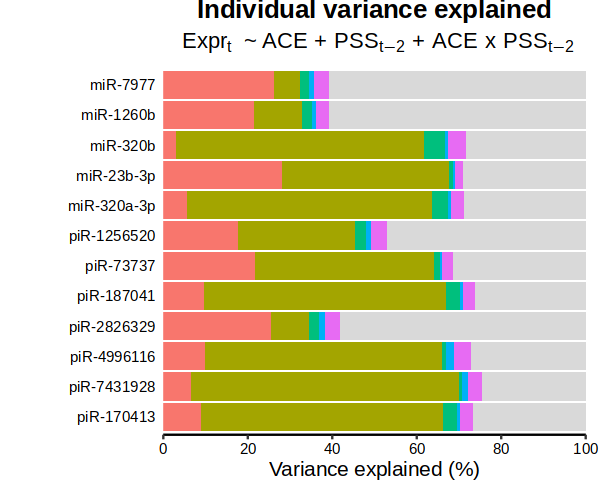

In [148]:
options(repr.plot.width = 5, repr.plot.height = 4)
rbind_eff_2m = rbind(miR_rand_eff_2m,piR_rand_eff_2m)
temp = rbind_eff_2m[rownames(rbind_eff_2m) %in% sig_PSS_2m,]

# pdf(file = "tamanho_de_efeito_PSS_2m.pdf",width = 6,height = 4)
plotPercentBars(temp) + ggtitle("Individual variance explained",
                                bquote(~Expr[t]~" ~ ACE +"~PSS[t-2]~"+"~ACE~x~PSS[t-2])) +
theme(plot.title = element_text(hjust = 0.5,size = 15, face = "bold"),
      plot.subtitle = element_text(hjust = 0.5,size = 13),
        axis.title.x = element_text(size = 12),
        axis.title.y = element_text(size = 12),
        legend.position = "none")
# dev.off()

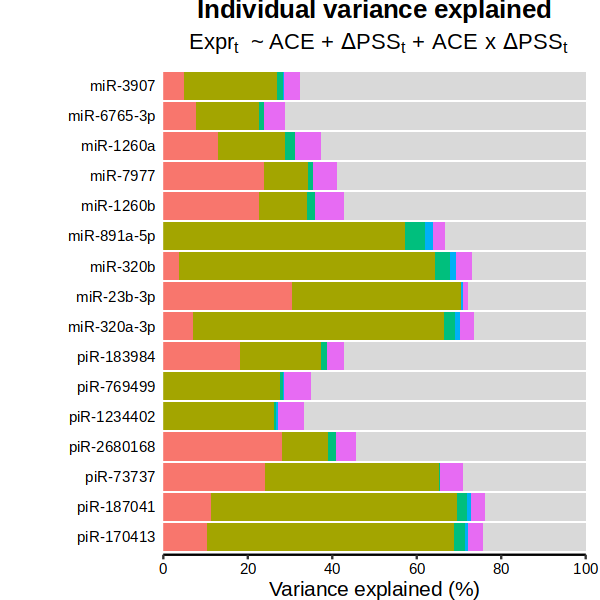

In [150]:
options(repr.plot.width = 5, repr.plot.height = 5)
rbind_eff_d1m = rbind(miR_rand_eff_d1m,piR_rand_eff_d1m)
temp = rbind_eff_d1m[rownames(rbind_eff_d1m) %in% sig_delta_PSS_acute,]

# pdf(file = "tamanho_de_efeito_deltaPSS_acute.pdf",width = 6,height = 5)
plotPercentBars(temp) + ggtitle("Individual variance explained",
                                bquote(~Expr[t]~" ~ ACE +"~Delta*PSS[t]~"+"~ACE~x~Delta*PSS[t])) +
theme(plot.title = element_text(hjust = 0.5,size = 15, face = "bold"),
      plot.subtitle = element_text(hjust = 0.5,size = 13),
        axis.title.x = element_text(size = 12),
        axis.title.y = element_text(size = 12),
      legend.position = "none")
# dev.off()

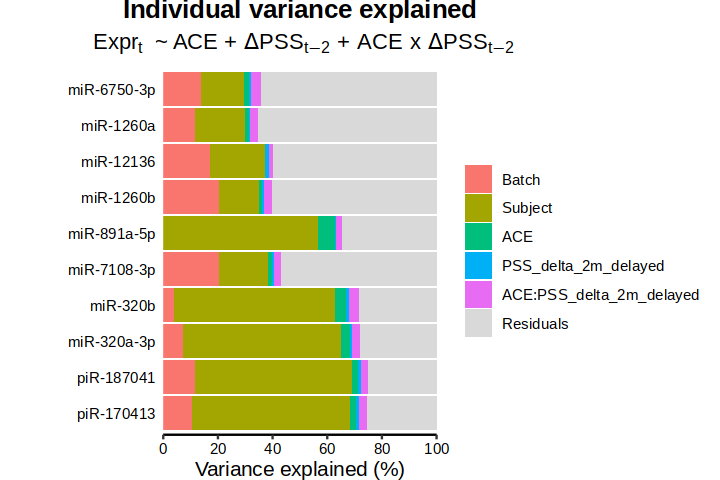

In [146]:
options(repr.plot.width = 5, repr.plot.height = 4)
rbind_eff_d3m = rbind(miR_rand_eff_d3m,piR_rand_eff_d3m)
temp = rbind_eff_d3m[rownames(rbind_eff_d3m) %in% sig_delta_PSS_2m,]

# pdf(file = "tamanho_de_efeito_deltaPSS_2m.pdf",width = 6,height = 4)
plotPercentBars(temp) + ggtitle("Individual variance explained",
                                bquote(~Expr[t]~" ~ ACE +"~Delta*PSS[t-2]~"+"~ACE~x~Delta*PSS[t-2])) +
theme(plot.title = element_text(hjust = 0.5,size = 15, face = "bold"),
      plot.subtitle = element_text(hjust = 0.5,size = 13),
        axis.title.x = element_text(size = 12),
        axis.title.y = element_text(size = 12),
      legend.position = "none")
# dev.off()

In [35]:
PSS_ACE_effects = miR_rand_eff_2m$`ACE:PSS_2m_prior`+miR_rand_eff_2m$PSS_2m_prior + miR_rand_eff_2m$PSS_2m_prior

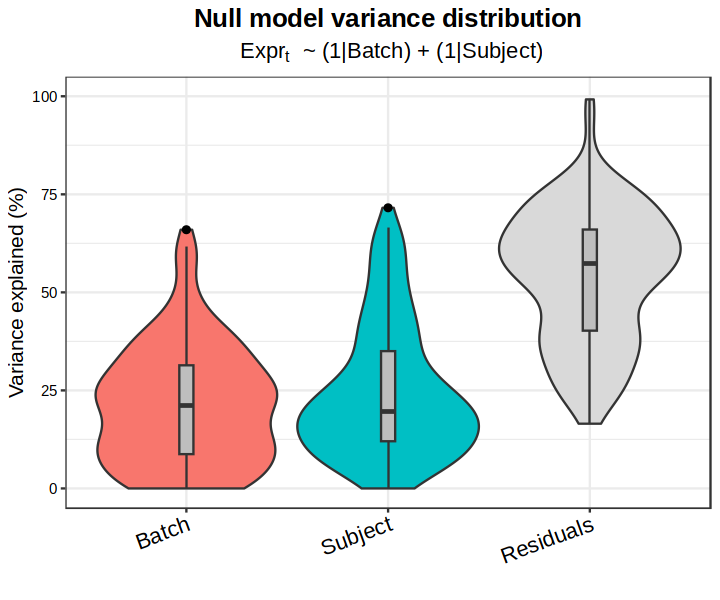

In [143]:
options(repr.plot.width = 6, repr.plot.height = 5)
# pdf(file = "tamanho_de_efeito_null.pdf",width = 6,height = 5)
plotVarPart(rbind_null_var) + ggtitle("Null model variance distribution",
                                              bquote(~Expr[t]~" ~ (1|Batch) + (1|Subject)")) +
theme(plot.title = element_text(hjust = 0.5,size = 15, face = "bold"),
      plot.subtitle = element_text(hjust = 0.5,size = 13),
        axis.title.x = element_text(size = 12),
        axis.title.y = element_text(size = 12)) + ylab("Variance explained (%)")
# dev.off()

In [52]:
## PROPORTION OF VARIANCE EXPLAINED BY BATCH AND INDIVIDUAL
a = plotPercentBars(miR_rand_eff_2m_sign) + ggtitle("miRNA individual variance explained",
                                              "Significant miRNAs models") +
theme(plot.title = element_text(hjust = 0.5,size = 15, face = "bold"),
      plot.subtitle = element_text(hjust = 0.5,size = 13),
        axis.title.x = element_text(size = 12),
        axis.title.y = element_text(size = 12))

b = plotVarPart(miR_rand_eff_2m) + ggtitle("miRNA variance explained distribution (All models)",
                                              bquote(~Expr[t]~" ~ ACE +"~PSS[t-2]~"+"~bold(ACE~x~PSS[t-2]))) +
theme(plot.title = element_text(hjust = 0.5,size = 15, face = "bold"),
      plot.subtitle = element_text(hjust = 0.5,size = 13),
        axis.title.x = element_text(size = 12),
        axis.title.y = element_text(size = 12))

c = plotPercentBars(miR_rand_eff_d3m_sign) + ggtitle("miRNA individual variance explained",
                                              "Significant miRNAs models") +
theme(plot.title = element_text(hjust = 0.5,size = 15, face = "bold"),
      plot.subtitle = element_text(hjust = 0.5,size = 13),
        axis.title.x = element_text(size = 12),
        axis.title.y = element_text(size = 12))

d = plotVarPart(miR_rand_eff_d3m) + ggtitle("miRNA variance explained distribution (All models)",
                                              bquote(~Expr[t]~" ~ ACE +"~Delta*PSS[t-2]~"+"~bold(ACE~x~Delta*PSS[t-2]))) +
theme(plot.title = element_text(hjust = 0.5,size = 15, face = "bold"),
      plot.subtitle = element_text(hjust = 0.5,size = 13),
        axis.title.x = element_text(size = 12),
        axis.title.y = element_text(size = 12))

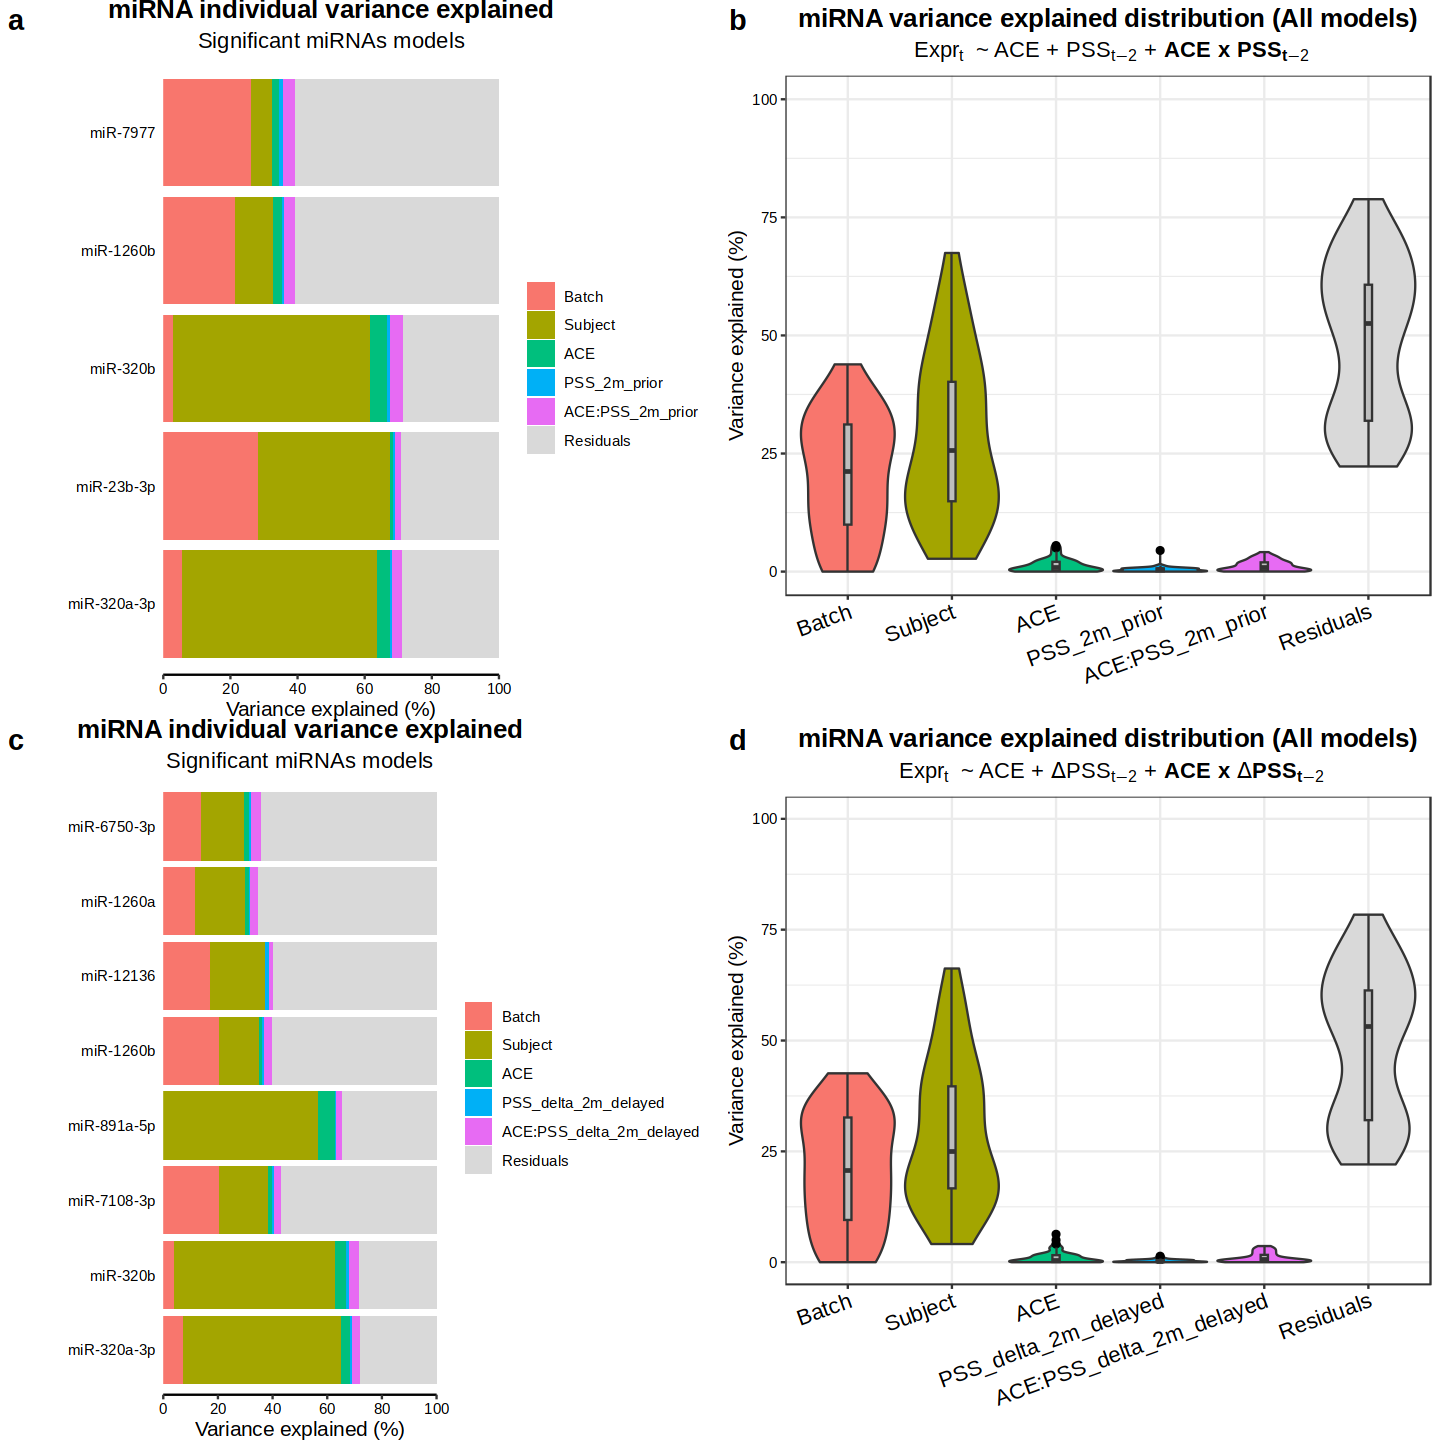

In [53]:
options(repr.plot.width = 12, repr.plot.height = 12)

pdf(file = "DREAM_predictor_variables_r2.pdf",width = 12,height = 12)
ggpubr::ggarrange(a, b,c,d, ncol = 2, nrow = 2,
                 labels = "auto",font.label = list(size=17,face="bold"))

dev.off()